# Periodic Variable Light Curve Simulation Pipeline

This notebook demonstrates the GP-based pipeline for generating synthetic Nancy Grace Roman Space Telescope light curves from variables observed by OGLE.


In [1]:
import pickle as pkl
import re
from pathlib import Path
from glob import glob
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from astropy.io import fits
from astropy.table import Table
import george
from george import kernels
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from functions import (
    prep_input, prep_gp, fit_gp,
    binning_data, multiscale_peaks, predict_gp,prep_for_fit,
    get_metrics, l2_distance, find_valid_rows, read_fits
)
from gp_model_params import info
from tqdm.notebook import tqdm
np.random.seed(42)

In [2]:
# Global matplotlib style for paper figures
plt.rcParams.update({
    "font.family"        : "serif",
    "font.size"          : 13,
    "axes.labelsize"     : 14,
    "axes.titlesize"     : 14,
    "legend.fontsize"    : 11,
    "xtick.direction"    : "in",
    "ytick.direction"    : "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "figure.dpi"         : 120,
})

# Color-blind-friendly palette
C0, C1, C2, C3, C4 = "#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7"

In [3]:
# Paths
home = str(Path.home())

# Source type — change to 'RRLYR' to switch object class
TP   = 'RRLYR'
BAND = 'I'

DIREC       = home + f'/Research_data/Bulge_Variables/{TP}/'
OUTPUT_PLOT = f'output/plots/{TP}/'
OUTPUT_FILE = 'output/'

Path(OUTPUT_PLOT).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_FILE).mkdir(parents=True, exist_ok=True)

# Period list (required for all periodic types that are not CV/DN/FL/BE)
period_file = home + f'/Research_data/Bulge_Variables/{TP}/BLG_{TP}_OGLE_periods.txt'
list_periods = np.genfromtxt(period_file, dtype='str')

# Keep a clean copy of the original n_phs so we can restore it after evaluation
n_phs_original = info[TP]['n_phs']

## Load Roman Cadence Arrays

The same three Roman cadences are used here as in the other pipelines, but for periodic variables only the short cadence is used in `run_all`; the long cadence is stored for downstream comparison.

In [5]:
# Load Roman Galactic Bulge cadence time arrays
Roman_sampling_short = np.load('lc_example/roman_times_shortcadence.npy')
Roman_sampling_long  = np.load('lc_example/roman_times_longcadence.npy')

# Normalise to start at t = 0
Roman_sampling_short -= Roman_sampling_short.min()
Roman_sampling_long  -= Roman_sampling_long.min()

Roman_max_short_time = Roman_sampling_short.max()

print(f"Short cadence : {len(Roman_sampling_short):,} pts  |  span = {Roman_max_short_time:.1f} d")
print(f"Long cadence  : {len(Roman_sampling_long):,} pts  |  span = {Roman_sampling_long.max():.1f} d")

Short cadence : 50,700 pts  |  span = 982.0 d
Long cadence  : 1,704 pts  |  span = 981.8 d


## Load a Single OGLE Cepheid Light Curve

In [6]:
# Select the example source specified in gp_model_params
# info[TP]['example'] gives the OGLE ID of a well-behaved representative source
demo_id   =  'OGLE-BLG-RRLYR-03609' #info[TP]['example']          # e.g. 'OGLE-BLG-CEP-019'
demo_path = DIREC + f'{demo_id}_multiband_lc.fits'

# Look up the known period from the catalogue
period_row = list_periods[list_periods[:, 0] == demo_id]
period     = float(period_row[0][1]) if len(period_row) > 0 else info[TP]['exp_period']

In [7]:
# Read the FITS file → multi-band DataFrame
# read_fits computes phase = (t / period) % 1 and shifts T_0 so phase 0.25
# aligns with the light curve minimum (faintest point).
period_fit, df_all = read_fits(demo_path, period=period, tp=TP)

# Isolate the I band
df = df_all[df_all.band == BAND].reset_index(drop=True)

print(f"I-band : {len(df):,} points  "
      f"| t ∈ [{df.t.min():.1f}, {df.t.max():.1f}] days  "
      f"| <m> = {df.m.mean():.3f}")
df.head()

I-band : 13,892 points  | t ∈ [0.0, 2714.8] days  | <m> = 18.231


,t,m,e,phase,band
0,0.00000,18.059,0.020,0.096982,I
1,0.04691,18.131,0.023,0.181066,I
2,0.93812,18.439,0.034,0.778521,I
3,1.97659,18.526,0.094,0.639933,I
4,3.96102,18.190,0.025,0.196937,I


In [8]:
info[TP]

{'kernel': CosineKernel(log_period=0.0, ndim=1, axes=array([0])) + Matern32Kernel(metric=Metric(0.0, ndim=1, axes=array([0]), bounds=[(None, None)]), block=None),
 'p0': [1, 0],
 'n_phs': 5,
 'p_range': [0.001, 1],
 'fit_binned': True,
 'count_per_bins': 150,
 'gp_opt': True,
 'p0_period': <function gp_model_params.<lambda>(x)>,
 'example': 'OGLE-BLG-RRLYR-03350',
 'exp_period': 0.51484451,
 'gp_opt_s_param': 5,
 'metric_threshold': 0.01,
 'metric_threshold_std': 0.01}

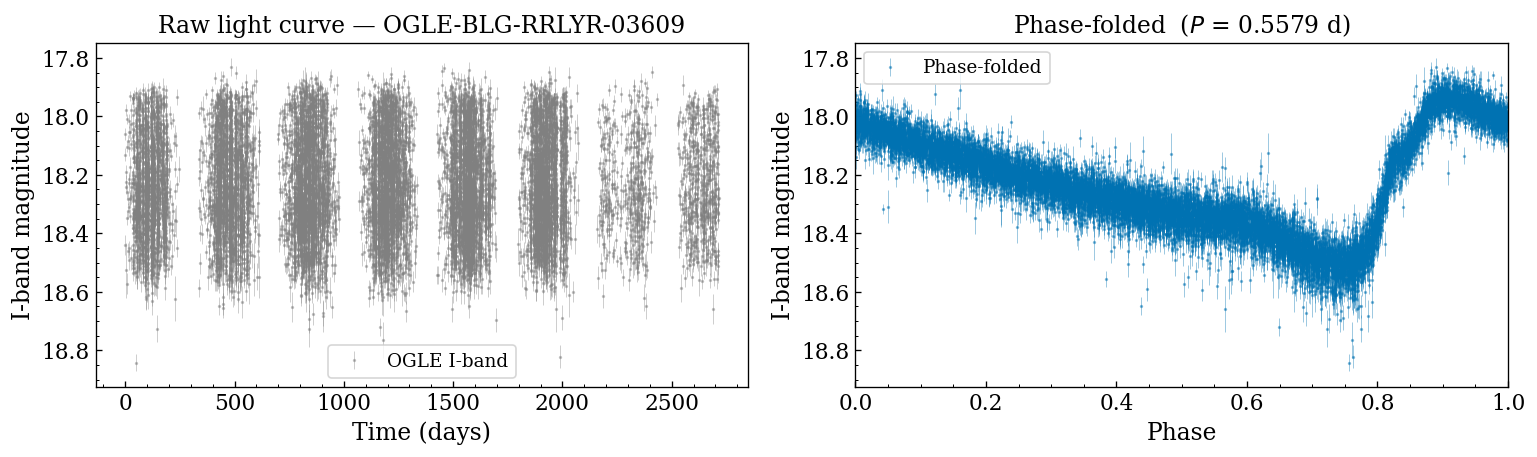

In [9]:
# Raw OGLE light curve (time domain)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Time domain
ax1.errorbar(df.t, df.m, yerr=df.e, fmt='.', color='grey',
             alpha=0.45, ms=2, lw=0.5, label='OGLE I-band')
ax1.invert_yaxis()
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('I-band magnitude')
ax1.set_title(f'Raw light curve — {demo_id}')
ax1.legend()
ax1.xaxis.set_minor_locator(AutoMinorLocator())

# Phase-folded (single period)
ax2.errorbar(df.phase, df.m, yerr=df.e, fmt='.', color=C0,
             alpha=0.45, ms=2, lw=0.5, label='Phase-folded')
ax2.invert_yaxis()
ax2.set_xlabel('Phase')
ax2.set_ylabel('I-band magnitude')
ax2.set_title(f'Phase-folded  ($P$ = {period:.4f} d)')
ax2.set_xlim(0, 1)
ax2.legend()
ax2.xaxis.set_minor_locator(AutoMinorLocator())

fig.tight_layout()
plt.savefig(OUTPUT_PLOT + f'fig1_{demo_id}_raw_lc.pdf', bbox_inches='tight')
plt.show()

## Preprocessing: Gap Reduction and Baseline Extension

`prep_for_fit` performs two operations specific to periodic variables:
1. **`gap_reducer`** — identifies large observing gaps (>100 d), determines how many full periods they span, and shifts subsequent data to compress the gap to an integer number of periods. This removes dead seasons without distorting the phase.
2. **`add_last_point` / `extend_baseline`** — if the total baseline is shorter than the Roman survey window (~982 d), a synthetic point is appended at the end (interpolated from the phase-folded LC), ensuring the GP can extrapolate to the full survey duration.

In [10]:
df_modified = prep_for_fit(df, period, info[TP])

In [11]:
info[TP]['p0_period']

<function gp_model_params.<lambda>(x)>

## Run the GP Pipeline

- data preparation → binning → GP initialisation → optimisation → prediction on the high cadence grids

In [12]:
# Initialise the GP kernel
from functions import prep_gp
import time

# prep_gp expects p0_period to remain a callable (lambda) — do NOT evaluate it.
# Only prep_for_fit has the np.isnan bug; we patch that separately (see Step 0).
gp = prep_gp(info[TP], period, verbose=True)
print("Kernel parameter vector:", gp.kernel.parameter_vector)

Setting up the GP...
Successfully set up the GP.
Kernel parameter vector: [-0.58358684  0.        ]


In [15]:
# Build the multi-phase input array (prep_input)
from functions import prep_input

t0 = time.time()
x, y, e = prep_input(df_modified, TP, period, info[TP], Roman_max_short_time)

In [16]:
# Bin the data
from functions import binning_data

t0 = time.time()

# Decide bin count the same way run_all does
if not np.isinf(info[TP]['n_phs']):
    if len(x) / info[TP]['n_phs'] > 150:
        info[TP]['fit_binned'] = True
        tot_ideal_len = info[TP]['n_phs'] * info[TP]['count_per_bins']
    else:
        info[TP]['fit_binned'] = False
        tot_ideal_len = np.nan
else:
    tot_ideal_len = 1500 if len(x) > 1500 else np.nan
    info[TP]['fit_binned'] = len(x) > 1500

x_binned, y_binned, e_binned, regular_sampling_fit = binning_data(
    x, y, e, info[TP], n_bins=tot_ideal_len
)

# Drop NaNs
valid = ~np.isnan(e_binned)
x_binned, y_binned, e_binned = x_binned[valid], y_binned[valid], e_binned[valid]

print(f"binning_data done in {time.time()-t0:.2f}s")
print(f"Binned size : {len(x_binned)} points  (from {len(x)})")
print(f"regular_sampling_fit size: {len(regular_sampling_fit)}")

binning_data done in 0.06s
Binned size : 750 points  (from 27784)
regular_sampling_fit size: 250


In [17]:
# Optimise kernel hyper-parameters
from functions import opt_gp

print("Running L-BFGS-B kernel optimisation …")
t0 = time.time()

if info[TP]['gp_opt']:
    gp.compute(x_binned, e_binned)
    gp = opt_gp(gp.kernel.parameter_vector, gp, x_binned, y_binned,
                s=info[TP]['gp_opt_s_param'])
    print(f"opt_gp done in {time.time()-t0:.2f}s")
    print("Optimised kernel params:", gp.kernel.parameter_vector)
else:
    # Even if skipping optimisation, compute() is still needed before predict()
    gp.compute(x_binned, e_binned)
    print("gp_opt=False — skipped optimisation, but gp.compute() called.")

y_median = np.median(y)

Running L-BFGS-B kernel optimisation …
opt_gp done in 0.46s
Optimised kernel params: [-0.58358684  0.        ]


In [27]:
cadence = 1 # in minutes
max_days = 2
CADENCE_DAYS = cadence / 1440.0 # 15 minutes expressed in days
t_start, t_stop = 0.0, max_days
regular_sampling_baseline = np.arange(t_start, t_stop + CADENCE_DAYS, CADENCE_DAYS) # ~19 201 points

print(f"Predicting on new baseline ({len(regular_sampling_baseline)} points, "
      f"{max_days} days at 1-min cadence) …")
t0 = time.time()
gp_y_baseline, cov_baseline = gp.predict(y_binned, regular_sampling_baseline)
gp_std_baseline = np.sqrt(np.diag(cov_baseline))
print(f"gp.predict (baseline) done in {time.time()-t0:.2f}s")

Predicting on new baseline (2881 points, 2 days at 1-min cadence) …
gp.predict (baseline) done in 0.52s


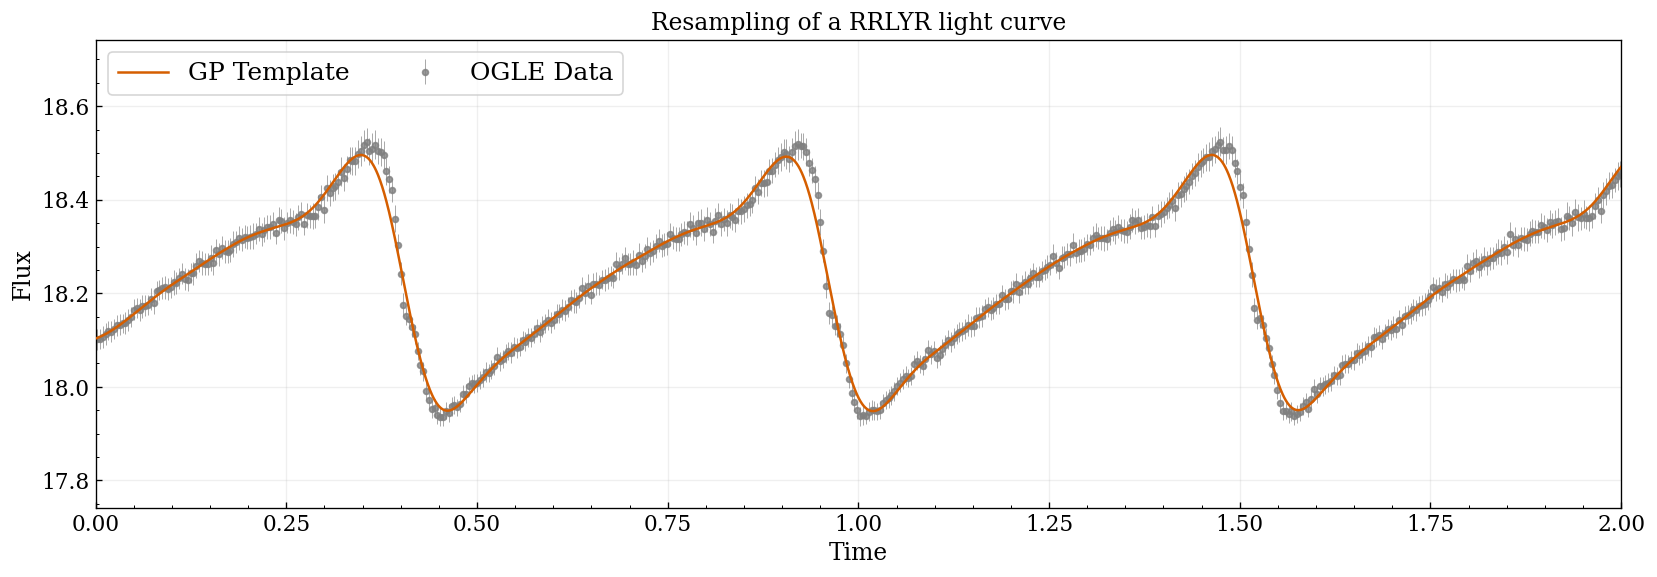

In [26]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# fit grid + baseline prediction
fig, ax = plt.subplots(figsize=(14, 5))

ax.errorbar(
    x_binned, y_binned+y_median, yerr=e_binned,
    fmt=".", color="grey", ms=7, lw=0.5, alpha=0.8, label="OGLE Data", zorder=2,
)

# GP prediction on new baseline
ax.plot(regular_sampling_baseline, gp_y_baseline+y_median, color=C3,
        lw=1.5, label=f"GP Template", zorder=3)
# ax.fill_between(
#     regular_sampling_baseline,
#     gp_y_baseline+y_median - 2 * gp_std_baseline,
#     gp_y_baseline+y_median + 2 * gp_std_baseline,
#     color=C3, alpha=0.2, label=r"GP $2\sigma$",
# )

ax.set_xlabel("Time")
ax.set_ylabel("Flux")
ax.set_title("Resampling of a %s light curve"%TP)
ax.legend(loc="upper left", fontsize=15, ncol=2)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 2)
ax.set_ylim(-0.5+y_median, 0.5+y_median)

plt.tight_layout()
plt.savefig(OUTPUT_PLOT+ "gp_baseline_prediction.png", dpi=150)
plt.show()